# Experiment 6: K-Means Clustering

**Course:** 23CSE301 — Machine Learning Lab  
**Topic:** Unsupervised K-Means Clustering with the Elbow Method  
**Dataset:** `datasets/Amazon_com_Clusturing_Model.csv` (200 rows, 5 columns: `Cus_ID`, `Sex`, `Age`, `Income`, `Rating`)  
**Lab Book Reference:** §10 K-Means Clustering, page 44–48

---

## 🎯 Objective

Apply the **K-Means** clustering algorithm to a customer dataset from Amazon
to discover natural customer segments.  We use the **Elbow Method** on the
Within-Cluster-Sum-of-Squares (WCSS) to pick the optimal number of clusters
`K`, then visualise the resulting clusters.

## 🧠 Key Concepts

- **Unsupervised learning:** no labels — the algorithm groups similar rows
  based on feature similarity alone.
- **K-Means algorithm:**
  1. Pick `K` initial centroids (using `k-means++` for smart initialisation).
  2. Assign each point to its nearest centroid (Euclidean distance).
  3. Recompute each centroid as the mean of its assigned points.
  4. Repeat steps 2-3 until assignments stop changing or `max_iter` reached.
- **WCSS (inertia):** sum of squared distances from each point to its assigned
  centroid.  Decreases monotonically with `K`.  The **elbow** in the WCSS-vs-K
  curve indicates the optimal `K`.
- **Feature scaling:** because K-Means uses Euclidean distance, features on
  different scales (here: `Income` is ~10⁶, `Age` is ~10¹, `Rating` is ~10²)
  **must** be standardised before clustering.

## ▶️ How to Run

> **Option A — Google Colab (recommended):**
> 1. Upload the entire `ML-Lab-Activities` folder to Google Drive.
> 2. Open `06-K-Means-Clustering/06_KMeans_Clustering.ipynb` from Drive in Colab.
>
> **Option B — Local Jupyter:**
> ```bash
> pip install -r requirements.txt
> jupyter notebook 06-K-Means-Clustering/06_KMeans_Clustering.ipynb
> ```
>
> **Option C — Headless:**
> ```bash
> jupyter nbconvert --to notebook --execute \
>   06-K-Means-Clustering/06_KMeans_Clustering.ipynb --output 06_KMeans_Clustering.ipynb
> ```

Datasets are read from `datasets/` (relative to the notebook's folder).
Generated figures are **auto-saved** to `./outputs/`.


In [1]:
# === Environment setup (works in both Google Colab and local Jupyter) ===
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/ML-Lab-Activities-Complete'
    os.chdir(os.path.join(BASE, '06-K-Means-Clustering'))
    print(f'Running in Google Colab. CWD: {os.getcwd()}')
else:
    print(f'Running locally. CWD: {os.getcwd()}')

OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Patch plt.show so every figure is also auto-saved as PNG
import matplotlib.pyplot as plt
_fig_counter = [0]
_orig_plt_show = plt.show
def _save_and_show(*args, **kwargs):
    for fnum in plt.get_fignums():
        _fig_counter[0] += 1
        fig = plt.figure(fnum)
        fname = f'figure_{_fig_counter[0]:03d}.png'
        try:
            fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=120, bbox_inches='tight')
        except Exception as e:
            print(f'Warning: could not save {fname}: {e}')
    _orig_plt_show(*args, **kwargs)
plt.show = _save_and_show

print('Setup complete. Figures will be auto-saved to:', OUTPUT_DIR)


Running locally. CWD: /home/z/my-project/work/build/ML-Lab-Activities/06-K-Means-Clustering


Setup complete. Figures will be auto-saved to: /home/z/my-project/work/build/ML-Lab-Activities/06-K-Means-Clustering/outputs


## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print('Libraries imported.')

Libraries imported.


## 2. Load & Explore the Dataset

The Amazon dataset has 200 customer records with `Cus_ID`, `Sex` (M/F),
`Age`, `Income`, and `Rating` (purchase rating 1-100).  Lab Book page 46.

In [3]:
data = pd.read_csv('datasets/Amazon_com_Clusturing_Model.csv')

print(f"Shape: {data.shape}")
display(data.head(10))
display(data.describe())
print("\nSex distribution:")
print(data['Sex'].value_counts())

Shape: (200, 5)


,Cus_ID,Sex,Age,Income,Rating
0,301219,M,37,581052,96
1,301220,F,25,288994,36
2,301221,F,38,492702,34
3,301222,M,36,734878,46
4,301223,F,31,318271,44
5,301224,M,60,1826710,64
6,301225,F,23,254669,53
7,301226,M,25,511166,85
8,301227,F,31,722308,31
9,301228,F,48,2453041,63


,Cus_ID,Age,Income,Rating
count,200.000000,200.000000,2.000000e+02,200.000000
mean,301318.500000,33.945000,7.806506e+05,56.320000
std,57.879185,10.181369,4.957218e+05,22.532112
min,301219.000000,19.000000,2.325070e+05,1.000000
25%,301268.750000,26.000000,3.859498e+05,38.750000
50%,301318.500000,31.000000,6.380670e+05,54.000000
75%,301368.250000,40.000000,8.459250e+05,74.000000
max,301418.000000,65.000000,2.453041e+06,98.000000



Sex distribution:
Sex
F    110
M     90
Name: count, dtype: int64


## 3. Check for Null Values

In [4]:
print("Null values per column:")
print(data.isnull().sum())
print(f"\nTotal null values: {data.isnull().sum().sum()}")

Null values per column:
Cus_ID    0
Sex       0
Age       0
Income    0
Rating    0
dtype: int64

Total null values: 0


## 4. Select Features for Clustering

Following the Lab Book (page 46), we cluster on `Age` (column index 2) and
`Rating` (column index 4).  These two features will be the axes of the
cluster scatter plot.

In [5]:
X = data.iloc[:, [2, 4]].values   # Age (col 2) and Rating (col 4)
print(f"X shape: {X.shape}")
print(f"First 5 rows of X (Age, Rating):")
print(X[:5])

X shape: (200, 2)
First 5 rows of X (Age, Rating):
[[37 96]
 [25 36]
 [38 34]
 [36 46]
 [31 44]]


## 5. Feature Scaling

Because `Age` (~25-50) and `Rating` (~20-100) have very different scales,
we standardise them before clustering.

In [6]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X)
print("Features standardised.")
print(f"First 5 rows of scaled X:")
print(X_scaled[:5].round(3))

Features standardised.
First 5 rows of scaled X:
[[ 0.301  1.765]
 [-0.881 -0.904]
 [ 0.399 -0.993]
 [ 0.202 -0.459]
 [-0.29  -0.548]]


## 6. Elbow Method — Find Optimal K

We compute K-Means for K = 1 to 10 and plot the WCSS (inertia) curve.  The
**elbow** (point where WCSS stops dropping sharply) indicates the optimal K.
Lab Book page 46 shows K = 4.

WCSS by K:
  K =  1  WCSS = 400.00
  K =  2  WCSS = 231.08
  K =  3  WCSS = 101.95
  K =  4  WCSS = 75.65
  K =  5  WCSS = 60.67
  K =  6  WCSS = 51.16
  K =  7  WCSS = 42.83
  K =  8  WCSS = 37.40
  K =  9  WCSS = 33.40
  K = 10  WCSS = 30.18


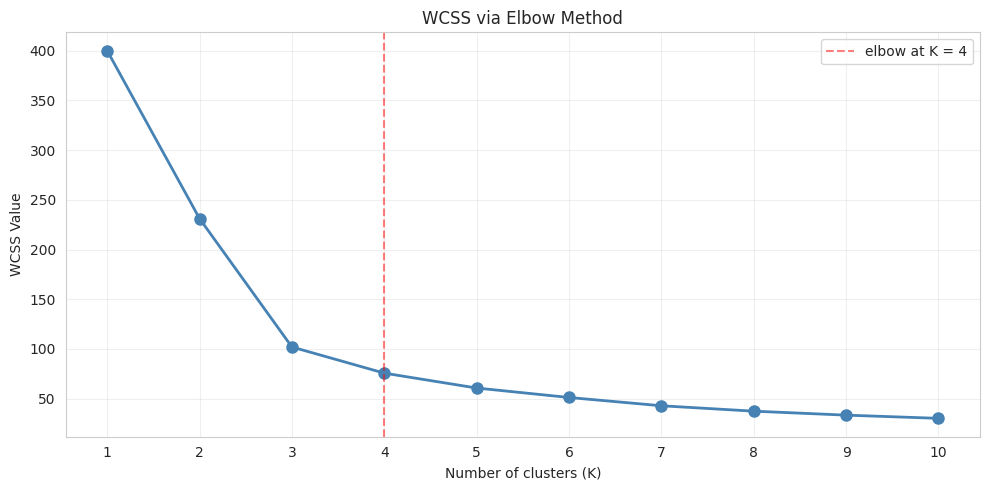

In [7]:
wcss = []
for k in range(1, 11):
    model = KMeans(n_clusters=k, init='k-means++', random_state=21, n_init=10)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

print("WCSS by K:")
for k, w in enumerate(wcss, 1):
    print(f"  K = {k:2d}  WCSS = {w:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, 'o-', color='steelblue', linewidth=2, markersize=8)
plt.axvline(4, color='red', linestyle='--', alpha=0.5, label='elbow at K = 4')
plt.title('WCSS via Elbow Method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS Value')
plt.xticks(range(1, 11))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 7. Train K-Means with K = 4

Lab Book page 47 uses `n_clusters=4` with `k-means++` initialisation.

In [8]:
model = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
y_means = model.fit_predict(X_scaled)

print("Cluster labels (first 40):")
print(y_means[:40])
print(f"\nUnique clusters: {np.unique(y_means)}")
print("Cluster sizes:", dict(zip(*np.unique(y_means, return_counts=True))))
print(f"\nFinal centroids (scaled):")
print(model.cluster_centers_)

Cluster labels (first 40):
[3 1 2 1 1 0 1 3 2 0 3 1 3 2 0 1 3 3 1 3 1 2 3 0 0 2 3 3 0 3 2 1 3 2 3 3 0
 1 2 0]

Unique clusters: [0 1 2 3]
Cluster sizes: {np.int32(0): np.int64(49), np.int32(1): np.int64(58), np.int32(2): np.int64(36), np.int32(3): np.int64(57)}

Final centroids (scaled):
[[ 1.4864109   0.06839129]
 [-0.64309587 -0.44995699]
 [ 0.07105897 -1.34777591]
 [-0.66829292  1.25028535]]


## 8. Visualise the Clusters

Scatter plot of `Age` vs `Rating` coloured by cluster, with the centroids
plotted as large black markers.  Lab Book page 47.

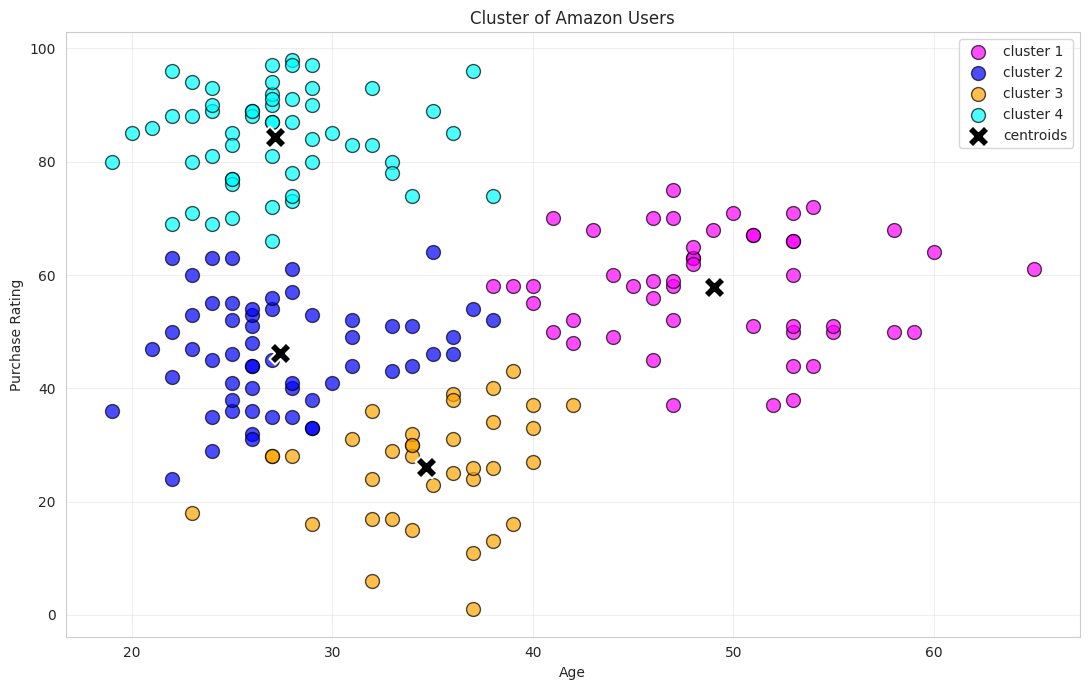

In [9]:
# Inverse-transform the centroids back to the original feature scale for plotting
centroids = sc.inverse_transform(model.cluster_centers_)
X_orig = X   # original (unscaled) Age & Rating

plt.figure(figsize=(11, 7))
colors = ['magenta', 'blue', 'orange', 'cyan']
for c in range(4):
    plt.scatter(X_orig[y_means == c, 0], X_orig[y_means == c, 1],
                s=100, c=colors[c], label=f'cluster {c+1}', edgecolors='k', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1],
            s=250, c='black', marker='X', label='centroids', edgecolors='white', linewidths=1.5)

plt.title('Cluster of Amazon Users')
plt.xlabel('Age')
plt.ylabel('Purchase Rating')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Silhouette Score (Model Validation)

The silhouette score measures how well each point fits its assigned cluster
relative to the nearest other cluster.  Values range from `-1` (worst) to
`+1` (best); values above `0.5` indicate a reasonable structure.

Silhouette score for K = 4: 0.4716


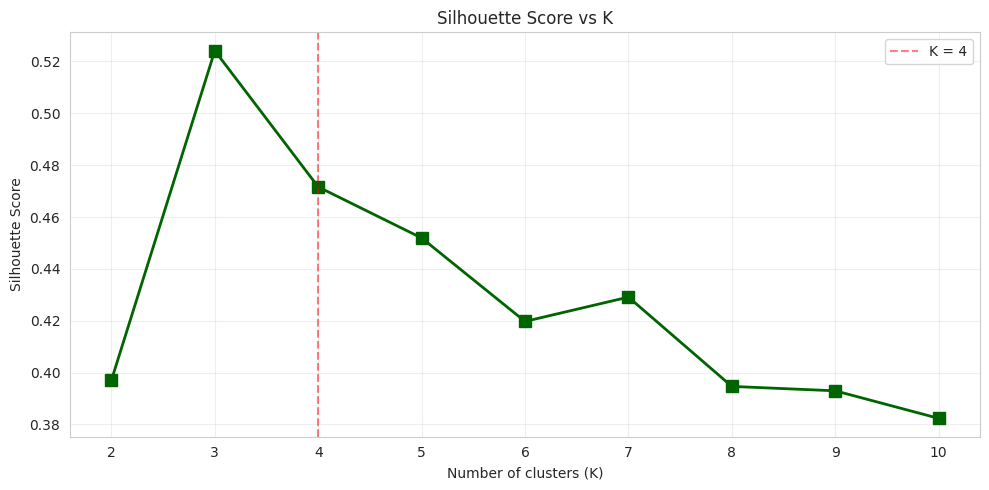

In [10]:
sil = silhouette_score(X_scaled, y_means)
print(f"Silhouette score for K = 4: {sil:.4f}")

# Sweep silhouette across multiple K to double-check the elbow
sil_scores = []
for k in range(2, 11):
    m = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = m.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), sil_scores, 's-', color='darkgreen', linewidth=2, markersize=8)
plt.axvline(4, color='red', linestyle='--', alpha=0.5, label='K = 4')
plt.title('Silhouette Score vs K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 10. Cluster Profiles — Mean Values per Cluster

Business-friendly summary of each cluster: mean Age, Income, Rating, plus
the sex ratio.

,n_customers,mean_age,mean_income,mean_rating,pct_female
Cluster,,,,,
0,49,49.04,1487788.51,57.86,53.06
1,58,27.41,439902.53,46.21,58.62
2,36,34.67,701627.67,26.03,55.56
3,57,27.16,569395.40,84.42,52.63


/tmp/ipykernel_4835/3595645348.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profile.index, y=profile[col], ax=ax, palette='viridis')
/tmp/ipykernel_4835/3595645348.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profile.index, y=profile[col], ax=ax, palette='viridis')
/tmp/ipykernel_4835/3595645348.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=profile.index, y=profile[col], ax=ax, palette='viridis')


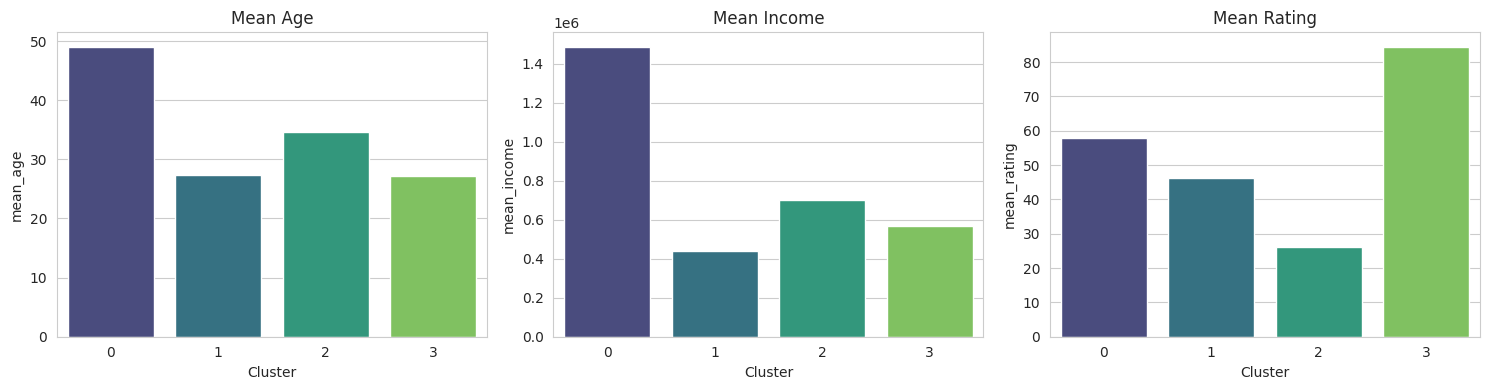

In [11]:
data['Cluster'] = y_means
profile = data.groupby('Cluster').agg(
    n_customers=('Cus_ID', 'count'),
    mean_age=('Age', 'mean'),
    mean_income=('Income', 'mean'),
    mean_rating=('Rating', 'mean'),
    pct_female=('Sex', lambda s: (s == 'F').mean() * 100),
).round(2)
display(profile)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes,
                         ['mean_age', 'mean_income', 'mean_rating'],
                         ['Mean Age', 'Mean Income', 'Mean Rating']):
    sns.barplot(x=profile.index, y=profile[col], ax=ax, palette='viridis')
    ax.set_title(title)
    ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()

## 📝 Exercises (Lab Book §10.6, page 48)

> Submit the Colab link or GitHub link or any `.ipynb` file for the exercises.

1. **Old Faithful geyser eruptions.** Implement K-Means clustering on the
   *Old Faithful* geyser eruption dataset (Yellowstone National Park, USA).
   Segregate the **waiting time between eruptions** vs the **duration of
   the eruption**.  Identify the two natural clusters (long/short).
   Dataset: `geyser` from seaborn (`sns.load_dataset('geyser')`) or the
   CSV at <https://www.stat.cmu.edu/~larry/all-of-statistics/=data/faithful.dat>.
2. **Image compression.** Use K-Means clustering to compress an image of
   size `396 × 396 × 3`.  Treat each pixel's RGB value as a 3-D point;
   cluster the pixel colors into K clusters (try K = 8, 16, 32); then
   reconstruct the image by replacing each pixel's color with its assigned
   cluster centroid.


## 📚 Key Takeaways

- **K-Means** partitions data into K spherical clusters by minimising WCSS.
- The **Elbow Method** (plot WCSS vs K) gives the optimal K; here K = 4.
- **Feature scaling** is essential — features with large ranges otherwise
  dominate the Euclidean distance.
- **k-means++ initialisation** is smarter than random initial centroids and
  avoids poor local minima.
- **Pros:** simple, fast, scales to large datasets, interpretable centroids.
- **Cons:** must specify K in advance; sensitive to outliers; assumes
  spherical, equal-variance clusters; can converge to local minima (mitigated
  by `n_init > 1`).


## 🔗 References

- Lab Activity Book (23CSE301), §10 K-Means Clustering, page 44–48.
- Scikit-learn user guide — K-Means:
  <https://scikit-learn.org/stable/modules/clustering.html#k-means>
